# Random Sample + Collate + Spectrogram
This cell pair picks a random local LibriSpeech sample, applies `collate_fn`, and visualizes the resulting mel spectrogram.

/Users/nikan/Desktop/PersonalProjects/Notarius/notariusvenv/lib/python3.13/site-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(
/Users/nikan/Desktop/PersonalProjects/Notarius/notariusvenv/lib/python3.13/site-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder ins

Train subset size: 200
Batch spectrogram shape: (12, 64, 2091)
Batch targets shape: (12, 313)
Input lengths (first 5): [582, 404, 676, 218, 473]
Target lengths (first 5): [80, 32, 112, 18, 77]


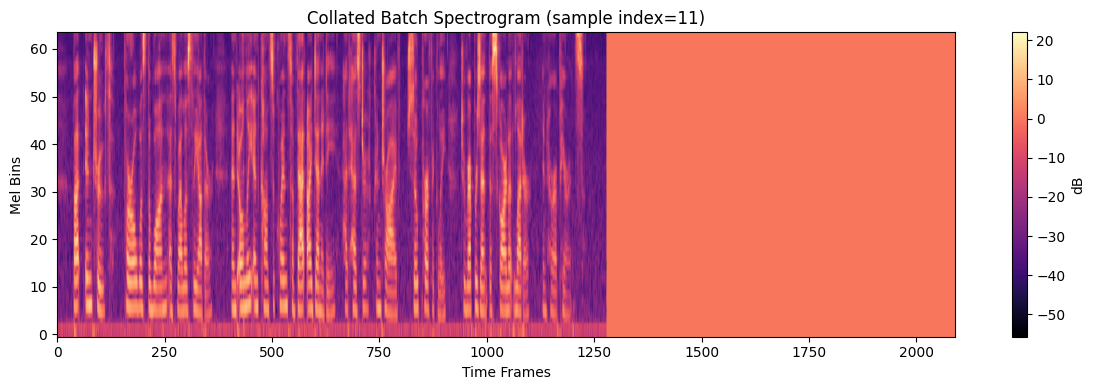

In [ ]:
import matplotlib.pyplot as plt
import torch
import torchaudio
from torch.utils.data import DataLoader, Subset

from model.helpers import collate_fn

# Same dataset setup style as train.py
root = "/Users/nikan/Desktop/PersonalProjects/Notarius/datasets"
train_ds = torchaudio.datasets.LIBRISPEECH(root=root, url="test-clean", download=True)

small_train_ds = Subset(train_ds, range(200))

# Apply collate function through DataLoader
train_loader = DataLoader(
    small_train_ds,
    batch_size=12,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=2,
)


Train subset size: 200
Batch spectrogram shape: (12, 64, 1855)
Batch targets shape: (12, 269)
Input lengths (first 5): [297, 773, 1066, 1665, 188]
Target lengths (first 5): [51, 101, 166, 269, 5]


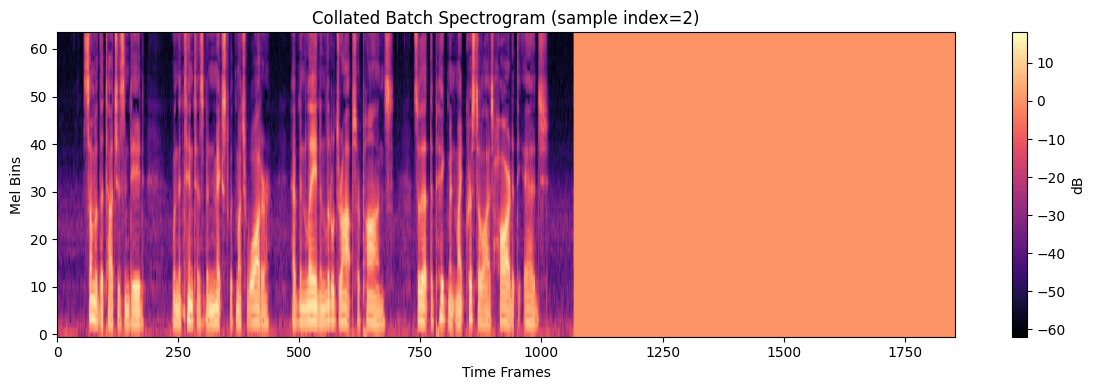

In [13]:

# Get one collated batch (this is your "df" / batch object)
df = next(iter(train_loader))
spectrogram_batch, targets_batch, input_lengths, target_lengths = df

print(f"Train subset size: {len(small_train_ds)}")
print(f"Batch spectrogram shape: {tuple(spectrogram_batch.shape)}")
print(f"Batch targets shape: {tuple(targets_batch.shape)}")
print(f"Input lengths (first 5): {input_lengths[:5].tolist()}")
print(f"Target lengths (first 5): {target_lengths[:5].tolist()}")

# Show spectrogram of one random item from the collated batch
idx = torch.randint(0, spectrogram_batch.shape[0], (1,)).item()
spec = spectrogram_batch[idx].detach().cpu().numpy()  # (n_mels, time)

plt.figure(figsize=(12, 4))
plt.imshow(spec, aspect="auto", origin="lower", cmap="magma")
plt.title(f"Collated Batch Spectrogram (sample index={idx})")
plt.xlabel("Time Frames")
plt.ylabel("Mel Bins")
plt.colorbar(label="dB")
plt.tight_layout()
plt.show()